# SHFLI Microwave Cavity Ring-Down Measurement

**Two-step workflow:**
1. **Frequency sweep** — identify cavity resonance (~3.75 GHz) using the sweeper module
2. **Ring-down** — excite with a 1 µs rectangular pulse via Timeline Module, capture free-decay envelope at 50 MSa/sec with 17 MHz bandwidth (filter bypass ON), fit to extract τ and Q

**Ring-down principle:** Q = π × f₀ × τ
where τ is the 1/e amplitude decay time constant.

In [1]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from zhinst.toolkit import Session

## Connect

In [2]:
device_id   = "dev12470"
server_host = "localhost"

session = Session(server_host, allow_version_mismatch=True)
shfli   = session.connect_device(device_id)

print(f"Connected: {device_id} on {server_host}")

Connected: dev12470 on localhost


## Parameters

In [3]:
# ── Hardware channels ─────────────────────────────────────────────────────────
DEMOD_INDEX = 0
OSC_INDEX   = 0
OUT_CH      = 0     # sigouts[0] — output to cavity drive port
IN_CH       = 0     # sigins[0]  — input from cavity transmit/reflect port
OP_RANGE    = -20   # dBm — output range
IP_RANGE    = -30   # dBm — input range (adjust if signal is too weak/strong)

# ── Part 1: CW sweep ──────────────────────────────────────────────────────────
CENTER_FREQ_GUESS = 3.75761e9   # Hz — rough resonance estimate
SWEEP_HALF_SPAN   = 10e6     # Hz — sweep ±10 MHz around center
SWEEP_POINTS      = 101
SWEEP_BW          = 1000     # Hz — demod bandwidth during sweep
DRIVE_VOLTAGE_CW  = 0.01     # scale 0–1 — small drive for CW sweep

# ── Part 2: Ring-down ─────────────────────────────────────────────────────────
PULSE_DURATION    = 1e-6     # s  — 1 µs rectangular excitation pulse
RINGDOWN_WINDOW   = 5e-6    # s  — silent capture window after pulse
REPETITION_WAIT   = 20e-6    # s  — dead time between repetitions
N_AVERAGES        = 1      # number of ring-down averages

DEMOD_RATE        = 50e6     # Sa/s — 50 MSa/sec output rate
FILTER_BW         = 17e6     # Hz  — 17 MHz bandwidth (bypass mode)
BURST_LEN         = int(RINGDOWN_WINDOW * DEMOD_RATE)   # 250 samples
DRIVE_AMPLITUDE   = 1.0      # full-scale excitation during pulse

print(f"Burst length       : {BURST_LEN} samples = {RINGDOWN_WINDOW*1e6:.0f} µs at {DEMOD_RATE/1e6:.0f} MSa/sec")
print(f"Total acquisition  : {N_AVERAGES} averages")

Burst length       : 250 samples = 5 µs at 50 MSa/sec
Total acquisition  : 1 averages


## Part 1 — Frequency Sweep (Resonance Identification)

In [4]:
# ── Configure SHFLI for CW sweep ─────────────────────────────────────────────
with shfli.set_transaction():
    shfli.demods[DEMOD_INDEX].enable(0)
    shfli.synthesizers[OSC_INDEX].centerfreq(CENTER_FREQ_GUESS)
    shfli.oscs[OSC_INDEX].freq(0.0)
    shfli.sigouts[OUT_CH].generators[3].enable(1)               # disable unused generators
    shfli.sigouts[OUT_CH].generators[0].amplitude(DRIVE_VOLTAGE_CW)
    shfli.sigouts[OUT_CH].on(1)
    shfli.sigouts[OUT_CH].range(OP_RANGE)
    shfli.sigins[IN_CH].range(IP_RANGE)
    shfli.demods[DEMOD_INDEX].order(3)
    shfli.demods[DEMOD_INDEX].timeconstant(1 / SWEEP_BW)
    shfli.demods[DEMOD_INDEX].rate(24e3)
    shfli.demods[DEMOD_INDEX].enable(1)
    shfli.demods[DEMOD_INDEX].trigger.triggeracq(0)

# ── Run sweeper ───────────────────────────────────────────────────────────────
read_node = shfli.demods[DEMOD_INDEX].sample
sweeper   = session.modules.sweeper

sweeper.device(shfli)
sweeper.xmapping(0)                          # 0 = linear
sweeper.settling.inaccuracy(1e-4)
sweeper.averaging.sample(1)
sweeper.samplecount(SWEEP_POINTS)
sweeper.averaging.tc(10)
sweeper.bandwidthcontrol(1)                  # 1 = fixed bandwidth
sweeper.bandwidth(SWEEP_BW)
sweeper.omegasuppression(40.0)
sweeper.order(4)
sweeper.gridnode(f'/{device_id}.multiband/sigins0/oscs0')
sweeper.start(CENTER_FREQ_GUESS - SWEEP_HALF_SPAN)
sweeper.stop(CENTER_FREQ_GUESS  + SWEEP_HALF_SPAN)
sweeper.endless(0)
sweeper.subscribe(read_node)
sweeper.execute()

print("Sweeping...", end="")
while sweeper.progress() < 1.0:
    time.sleep(0.5)
    print(f"  {sweeper.progress()*100:.0f}%", end="\r")

sweep_result = sweeper.read()
sweeper.finish()
sweeper.unsubscribe('*')
print("\nSweep done.")

  100%ng...  5%
Sweep done.


### Fit Lorentzian and extract resonance

Resonance  : f₀ = 3.755912 GHz
Q factor   : Q  = 1103
Linewidth  : BW = 3403.95 kHz
Expected τ : 0.094 µs  (ring-down 1/e amplitude)
→ Capture window 5 µs  (consider ≥10 µs)


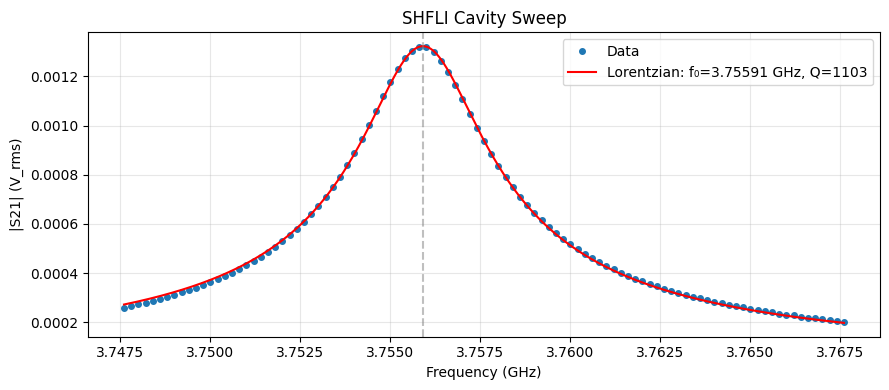


Center frequency set to: 3.755912 GHz


In [5]:
sweep_data = sweep_result[read_node][0][0]
freqs      = sweep_data['frequency']
R_data     = np.abs(sweep_data['x'] + 1j * sweep_data['y'])

def lorentzian(f, A, f0, Q, bg):
    return bg + A / np.sqrt(1 + 4*Q**2 * ((f - f0)/f0)**2)

f0_guess = freqs[np.argmax(R_data)]
Q_guess  = f0_guess / ((freqs[-1] - freqs[0]) / 5)

try:
    popt, _ = curve_fit(
        lorentzian, freqs, R_data,
        p0=[R_data.max() - R_data.min(), f0_guess, Q_guess, R_data.min()],
        bounds=([0, freqs[0], 10, 0], [np.inf, freqs[-1], 1e8, np.inf])
    )
    f0_fit, Q_fit = popt[1], popt[2]
    BW_fit   = f0_fit / Q_fit
    tau_est  = Q_fit / (np.pi * f0_fit)   # expected ring-down time constant
    print(f"Resonance  : f₀ = {f0_fit/1e9:.6f} GHz")
    print(f"Q factor   : Q  = {Q_fit:.0f}")
    print(f"Linewidth  : BW = {BW_fit/1e3:.2f} kHz")
    print(f"Expected τ : {tau_est*1e6:.3f} µs  (ring-down 1/e amplitude)")
    cap_rec = max(5 * tau_est, 10e-6)
    print(f"→ Capture window {RINGDOWN_WINDOW*1e6:.0f} µs  "
          f"({'OK' if RINGDOWN_WINDOW >= cap_rec else f'consider ≥{cap_rec*1e6:.0f} µs'})") 
except Exception as e:
    f0_fit, Q_fit, BW_fit = f0_guess, None, None
    print(f"Fit failed ({e}) — using peak: f₀ = {f0_fit/1e9:.6f} GHz")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(freqs/1e9, R_data, 'o', ms=4, label='Data')
if Q_fit is not None:
    f_fine = np.linspace(freqs[0], freqs[-1], 1000)
    ax.plot(f_fine/1e9, lorentzian(f_fine, *popt), 'r-',
            label=f'Lorentzian: f₀={f0_fit/1e9:.5f} GHz, Q={Q_fit:.0f}')
ax.axvline(f0_fit/1e9, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('|S21| (V_rms)')
ax.set_title('SHFLI Cavity Sweep')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Update center frequency to resonance ──────────────────────────────────────
center_freq = f0_fit
print(f"\nCenter frequency set to: {center_freq/1e9:.6f} GHz")

## Part 2 — Ring-Down Measurement

Reconfigure SHFLI: 50 MSa/sec, 17 MHz bandwidth, **filter bypass ON**.

### Configure SHFLI for ring-down acquisition

In [58]:
# ── Re-tune synthesizer to measured resonance, configure high-rate demod ────
with shfli.set_transaction():
    shfli.demods[DEMOD_INDEX].enable(0)
    shfli.synthesizers[OSC_INDEX].centerfreq(center_freq)   # tune to exact resonance
    shfli.oscs[OSC_INDEX].freq(0.0)                          # demodulate at carrier
    shfli.sigins[IN_CH].range(IP_RANGE)
    shfli.sigouts[OUT_CH].range(OP_RANGE)
    shfli.sigouts[OUT_CH].generators[0].amplitude(DRIVE_AMPLITUDE)
    shfli.sigouts[OUT_CH].on(1)
    shfli.demods[DEMOD_INDEX].rate(DEMOD_RATE)               # 50 MSa/sec
    shfli.demods[DEMOD_INDEX].burstlen(BURST_LEN)
    shfli.demods[DEMOD_INDEX].bypass(1)                      # filter bypass ON
    shfli.demods[DEMOD_INDEX].trigger.triggeracq(1)          # burst trigger on trig-index
    shfli.demods[DEMOD_INDEX].enable(1)

print(f"SHFLI configured for ring-down:")
print(f"  Center freq   : {center_freq/1e9:.6f} GHz")
print(f"  Demod rate    : {DEMOD_RATE/1e6:.0f} MSa/sec")
print(f"  Burst length  : {BURST_LEN} samples ({RINGDOWN_WINDOW*1e6:.0f} µs)")
print(f"  Filter bypass : ON (17 MHz BW)")

SHFLI configured for ring-down:
  Center freq   : 3.755912 GHz
  Demod rate    : 50 MSa/sec
  Burst length  : 250 samples (6 µs)
  Filter bypass : ON (17 MHz BW)


### Configure Scope module

In [59]:
shfli.synthesizers[OSC_INDEX].centerfreq(3.6e9)   # tune to exact resonance
shfli.oscs[OSC_INDEX].freq(156e6) 

scope = session.modules.scope

scope.subscribe('/dev12470/scopes/0/channels/0/wave')
scope.subscribe('/dev12470/scopes/0/channels/1/wave')
#scope.averager.weight(10)
#scope.averager.restart(0)
scope.mode(1)
session.devices[device_id].scopes[0].single(1)
session.devices[device_id].scopes[0].trigger.channel(16)
session.devices[device_id].scopes[0].trigger.enable(1)

scope.save.directory('/home/app/Zurich Instruments/LabOne/WebServer')

### Define Timeline pulse sequence

Sequence: **1 µs rectangular pulse → trigger DAQ → silent ring-down window × N_AVERAGES**

The `measurement` element at the end of the pulse sends a trigger-index event to the demodulator,
which the DAQ module uses to start capturing the ring-down.

In [60]:
PULSE_DURATION = 2e-6
RINGDOWN_WINDOW = 6e-6
REPETITION_WAIT = 1e-6
SCOPE_RATE = 2e9
DEMOD_RATE = 50e6
GAIN = 0.5

SECTION_DURATION = PULSE_DURATION + RINGDOWN_WINDOW + REPETITION_WAIT

tlm = session.modules.timeline
tlm.device(device_id)
tlm.sequence.sourcestring('{\"meta\":{\"schemaVersion\":\"1.0.0\"},\"block\":{\"type\":\"block\",\"iterations\":1,\"sequence\":[{\"type\":\"section\",\"minDuration\":0E0,\"sectionMeasurements\":{\"scope0\":{\"rate\":2E9},\"demod0\":{\"rate\":5E7}},\"signals\":{\"sigout0\":[{\"type\":\"pulse\",\"waveform\":\"rect\",\"amplitude\":1E0,\"duration\":1E-6},{\"type\":\"delay\",\"duration\":4E-6}]}}]}}')
tlm.sigouts[0].modulation.type(2)
tlm.sigouts[1].modulation.type(0)

signal_paths = [
    f"/{shfli.serial}/demods/0/sample.x",
    f"/{shfli.serial}/demods/0/sample.y",
 ]

tlm.subscribe(signal_paths)

scope.execute()

time.sleep(1)

tlm.execute()

start = time.time()
timeout_seconds = 2
while not tlm.finished():
     if time.time() - start > timeout_seconds:
          print("Timeout reached. Stopping timeline execution.")
          tlm.finish()
          break    
     time.sleep(0.3)
     #print(f"Progress: {tlm.progress()[0] * 100:.0f} %\r")

daq_data = tlm.read()

scope_data = 0

# while scope.progress() < 1.0 and not scope.finished():
#      time.sleep(1)
#      scope_data  = scope_data
#      print(f"Progress {float(scope.progress()) * 100:.2f} %\r")
scope_data = scope.read()

if scope_data:
    print("Got data")
else:
    print("Empty")

time.sleep(2)
tlm.unsubscribe("*")
scope.unsubscribe("*")

print("Timeline module destroyed.")
print("Scope disconnected.")

Got data
Timeline module destroyed.
Scope disconnected.


### Plot ring-down and fit exponential decay

Pulse-off detected : 1.560 µs  (sample 78 of 250)
Ring-up  window : 74 samples,  1.460 µs
Ring-down window: 167 samples,  3.420 µs
Log-linear τ estimate: 1.144 µs

Ring-UP  fit:  τ_up   = 0.5450 ± 0.1055 µs   Q = 6431
Ring-DOWN fit: τ_down = 0.0892 ± 0.0009 µs   Q = 1052   BW = 3569.74 kHz


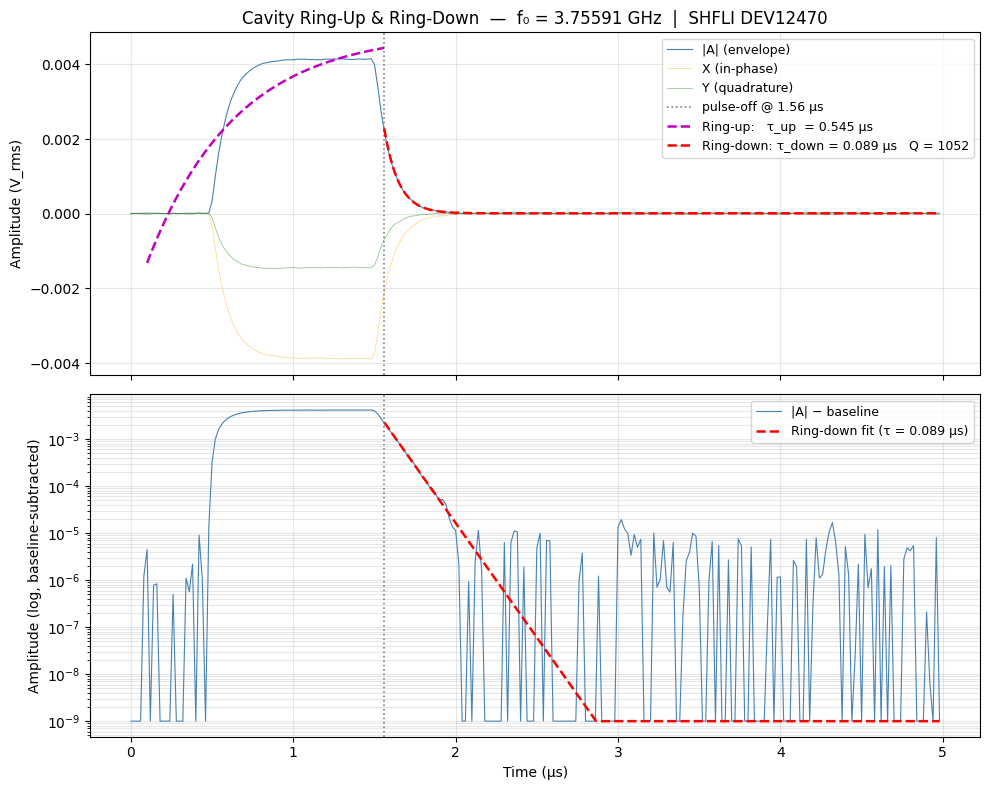

In [61]:
from scipy.ndimage import gaussian_filter1d

x_arr = daq_data[signal_paths[0]][0]['value'][0,:]
y_arr = daq_data[signal_paths[1]][0]['value'][0,:]
r_arr = np.abs(x_arr + 1j * y_arr)
t_us  = np.arange(len(r_arr)) / DEMOD_RATE * 1e6   # µs

# ── Detect pulse-off: steepest downward gradient of smoothed envelope ─────────
# More reliable than argmax, which is thrown off by noise spikes.
r_smooth = gaussian_filter1d(r_arr.astype(float), sigma=5)
i_off    = int(np.argmin(np.gradient(r_smooth)))
t_off    = t_us[i_off]
print(f"Pulse-off detected : {t_off:.3f} µs  (sample {i_off} of {len(r_arr)})")

# ── Data windows — skip a few samples at each boundary ───────────────────────
N_SKIP = 5   # samples to drop at start of ring-up and start of ring-down

i_up_start = N_SKIP
i_dn_start = i_off + N_SKIP

t_up   = t_us[i_up_start : i_off + 1] - t_us[i_up_start]   # t=0 at start of ring-up
r_up   = r_arr[i_up_start : i_off + 1]

t_dn   = t_us[i_dn_start :] - t_us[i_off]                  # t=0 at pulse-off
r_dn   = r_arr[i_dn_start :]

print(f"Ring-up  window : {len(t_up)} samples,  {t_up[-1]:.3f} µs")
print(f"Ring-down window: {len(t_dn)} samples,  {t_dn[-1]:.3f} µs")

# ── Initial τ estimate: log-linear regression on ring-down ────────────────────
bg_raw = r_dn[-10:].mean()
r_log  = np.log(np.maximum(r_dn - bg_raw, r_dn.max() * 1e-4))
slope, _ = np.polyfit(t_dn, r_log, 1)
tau_guess = max(-1.0 / slope, 0.01) if slope < 0 else t_dn[-1] / 4
print(f"Log-linear τ estimate: {tau_guess:.3f} µs")

# ── Model functions ────────────────────────────────────────────────────────────
def exp_rise(t, A_ss, tau, bg):
    return bg + A_ss * (1.0 - np.exp(-t / tau))

def exp_decay(t, A0, tau, bg):
    return bg + A0 * np.exp(-t / tau)

# ── Ring-up fit ────────────────────────────────────────────────────────────────
tau_up_us = None; popt_up = None; Q_up = None
try:
    # A_ss may be larger than r_up.max() if cavity isn't saturated → use 2× max
    p0_up = [r_up.max() * 2, tau_guess, r_up[0]]
    popt_up, pcov_up = curve_fit(
        exp_rise, t_up, r_up, p0=p0_up, maxfev=50000,
        bounds=([0, 1e-3, -np.inf], [np.inf, np.inf, np.inf])
    )
    A_ss_up, tau_up_us, bg_up = popt_up
    tau_up_err = np.sqrt(np.diag(pcov_up))[1]
    Q_up = np.pi * center_freq * tau_up_us * 1e-6
    print(f"\nRing-UP  fit:  τ_up   = {tau_up_us:.4f} ± {tau_up_err:.4f} µs   Q = {Q_up:.0f}")
except Exception as e:
    print(f"Ring-up fit failed: {e}")

# ── Ring-down fit ──────────────────────────────────────────────────────────────
tau_down_us = None; popt_down = None; Q_down = None; A0_d = None
try:
    p0_dn = [r_dn[0] - bg_raw, tau_guess, bg_raw]
    popt_down, pcov_down = curve_fit(
        exp_decay, t_dn, r_dn, p0=p0_dn, maxfev=50000,
        bounds=([0, 1e-3, -np.inf], [np.inf, np.inf, np.inf])
    )
    A0_d, tau_down_us, bg_dn = popt_down
    tau_dn_err = np.sqrt(np.diag(pcov_down))[1]
    Q_down = np.pi * center_freq * tau_down_us * 1e-6
    print(f"Ring-DOWN fit: τ_down = {tau_down_us:.4f} ± {tau_dn_err:.4f} µs   Q = {Q_down:.0f}   BW = {center_freq/Q_down/1e3:.2f} kHz")
except Exception as e:
    print(f"Ring-down fit failed: {e}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Linear — full trace + both fits
ax1.plot(t_us, r_arr, lw=0.8, color='steelblue', label='|A| (envelope)')
ax1.plot(t_us, x_arr, lw=0.5, color='orange', alpha=0.5, label='X (in-phase)')
ax1.plot(t_us, y_arr, lw=0.5, color='green',  alpha=0.5, label='Y (quadrature)')
ax1.axvline(t_off, color='gray', ls=':', lw=1.2, label=f'pulse-off @ {t_off:.2f} µs')

if popt_up is not None:
    tf = np.linspace(0, t_up[-1], 500)
    ax1.plot(tf + t_us[i_up_start], exp_rise(tf, *popt_up), 'm--', lw=1.8,
             label=f'Ring-up:   τ_up  = {tau_up_us:.3f} µs')

if popt_down is not None:
    tf = np.linspace(0, t_dn[-1], 500)
    ax1.plot(tf + t_us[i_off], exp_decay(tf, *popt_down), 'r--', lw=1.8,
             label=f'Ring-down: τ_down = {tau_down_us:.3f} µs   Q = {Q_down:.0f}')

ax1.set_ylabel('Amplitude (V_rms)')
ax1.set_title(f'Cavity Ring-Up & Ring-Down  —  f₀ = {center_freq/1e9:.5f} GHz  |  SHFLI {device_id.upper()}')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Log — ring-down only, baseline-subtracted
baseline = r_arr[-10:].mean()
r_base   = np.maximum(r_arr - baseline, 1e-9)
ax2.semilogy(t_us, r_base, lw=0.8, color='steelblue', label='|A| − baseline')
if popt_down is not None and A0_d is not None:
    tf = np.linspace(0, t_dn[-1], 500)
    ax2.semilogy(tf + t_us[i_off],
                 np.maximum(A0_d * np.exp(-tf / tau_down_us), 1e-9),
                 'r--', lw=1.8, label=f'Ring-down fit (τ = {tau_down_us:.3f} µs)')
ax2.axvline(t_off, color='gray', ls=':', lw=1.2)
ax2.set_ylabel('Amplitude (log, baseline-subtracted)')
ax2.set_xlabel('Time (µs)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

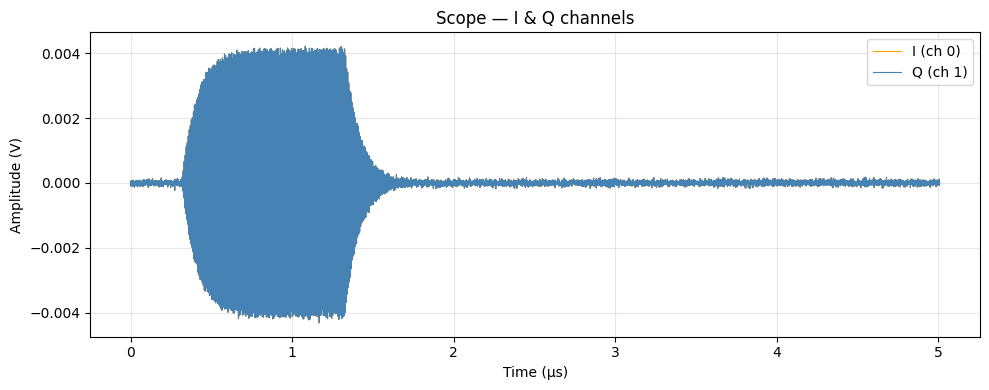

In [62]:
I_quad = scope_data['/dev12470/scopes/0/channels/0/wave'][0][0]['wave'][0,:]
Q_quad = scope_data['/dev12470/scopes/0/channels/1/wave'][0][0]['wave'][0,:]
dt     = scope_data['/dev12470/scopes/0/channels/1/wave'][0][0]['dt']

t_scope = np.arange(len(I_quad)) * dt * 1e6   # µs

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_scope, I_quad, lw=0.8, color='orange', label='I (ch 0)')
ax.plot(t_scope, Q_quad, lw=0.8, color='steelblue', label='Q (ch 1)')
ax.set_xlabel('Time (µs)')
ax.set_ylabel('Amplitude (V)')
ax.set_title('Scope — I & Q channels')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()